# Test 23: Коэффициенты в многослойной архитектуре

**Контекст:**
- Тест 9: многослойная архитектура на Logistic Map → a=4 оптимально
- Тест 22: однослойный SAE на 4 доменах → a=0.5-1 оптимально
- Гипотеза: промежуточные слои масштабируют входы, sin(a·x) получает другой диапазон

**План:**
- Те же 4 домена и тот же sweep a × w что в тесте 22
- Многослойная архитектура: input → Dense(256) → act → Dense(latent) → act → TopK → Dense(256) → act → output
- Сравнить оптимальный a с тестом 22
- **Если a сдвигается вверх** → подтверждает что a масштабируется с глубиной
- **Если a остаётся** → значит дело не в архитектуре

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# === Генерация данных (идентично тесту 22) ===

def generate_logistic_map(n_samples=5000, dim=64, r=3.99):
    data = []
    for _ in range(n_samples):
        x = np.random.rand()
        seq = []
        for _ in range(dim + 100):
            x = r * x * (1 - x)
            seq.append(x)
        data.append(seq[100:100+dim])
    return np.array(data, dtype='float32')

def generate_lorenz96(n_samples=5000, dim=64, F=8.0, dt=0.005, steps=2000):
    N = dim
    data = []
    attempts = 0
    while len(data) < n_samples and attempts < n_samples * 3:
        attempts += 1
        x = np.random.randn(N) * 0.01
        x[0] += F
        blown = False
        for _ in range(steps):
            dx = np.zeros(N)
            for i in range(N):
                dx[i] = (x[(i+1)%N] - x[(i-2)%N]) * x[(i-1)%N] - x[i] + F
            x = x + dt * dx
            if np.any(np.abs(x) > 1e6) or np.any(np.isnan(x)):
                blown = True
                break
        if not blown and np.all(np.isfinite(x)):
            data.append(x.copy())
    return np.array(data[:n_samples], dtype='float32')

def generate_sinusoidal(n_samples=5000, dim=64):
    data = []
    t = np.linspace(0, 2*np.pi, dim)
    for _ in range(n_samples):
        n_waves = np.random.randint(2, 6)
        signal = np.zeros(dim)
        for _ in range(n_waves):
            freq = np.random.uniform(0.5, 5.0)
            amp = np.random.uniform(0.2, 1.0)
            phase = np.random.uniform(0, 2*np.pi)
            signal += amp * np.sin(freq * t + phase)
        data.append(signal)
    return np.array(data, dtype='float32')

def load_mnist_flat(dim=64):
    (x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
    x_all = np.concatenate([x_train, x_test]).astype('float32') / 255.0
    x_flat = x_all.reshape(x_all.shape[0], -1)[:, :dim]
    return x_flat

np.random.seed(42)
domains = {
    'Logistic Map': generate_logistic_map(5000, 64),
    'Lorenz-96': generate_lorenz96(5000, 64),
    'Sinusoidal': generate_sinusoidal(5000, 64),
    'MNIST': load_mnist_flat(64),
}

for name, data in domains.items():
    print(f"{name:15s}: shape={data.shape}, range=[{data.min():.3f}, {data.max():.3f}], std={data.std():.3f}")

Logistic Map   : shape=(5000, 64), range=[0.010, 0.998], std=0.340
Lorenz-96      : shape=(5000, 64), range=[-12.220, 15.148], std=3.758
Sinusoidal     : shape=(5000, 64), range=[-4.013, 3.800], std=0.852
MNIST          : shape=(70000, 64), range=[0.000, 1.000], std=0.009


In [3]:
# === Многослойный SAE (как в тестах 9, 12) ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k
    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1)
        return inputs * mask
    def get_config(self):
        config = super().get_config()
        config.update({'k': self.k})
        return config


def build_multilayer_sae(input_dim, latent_dim, k_active, a=1.0, w=0.5, b=4.0):
    """Многослойный SAE: input → 256 → latent → 256 → output."""
    def act_fn(x):
        return tf.sin(a * x) + w * tf.tanh(b * x)
    
    inp = keras.Input(shape=(input_dim,))
    # Encoder: два слоя
    x = layers.Dense(256)(inp)
    x = layers.Activation(act_fn)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(act_fn)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(inp, latent, name='encoder')
    # Decoder: два слоя
    x = layers.Dense(256)(latent)
    x = layers.Activation(act_fn)(x)
    decoded = layers.Dense(input_dim, name='output')(x)
    autoencoder = keras.Model(inp, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


print('Multilayer SAE ready.')

Multilayer SAE ready.


In [4]:
# === 2D Sweep a × w (многослойная архитектура) ===

A_VALUES = [0.5, 1, 2, 4, 8, 16]
W_VALUES = [0.1, 0.25, 0.5, 0.75, 1.0]
B_FIXED = 4.0
NUM_RUNS = 3
EPOCHS = 10
BATCH_SIZE = 128
INPUT_DIM = 64
LATENT_DIM = 128
K_ACTIVE = 32

print(f'Sweep: {len(A_VALUES)} a × {len(W_VALUES)} w × {len(domains)} domains × {NUM_RUNS} runs')
print(f'= {len(A_VALUES)*len(W_VALUES)*len(domains)*NUM_RUNS} trainings')
print(f'Architecture: {INPUT_DIM} → 256 → {LATENT_DIM} → TopK({K_ACTIVE}) → 256 → {INPUT_DIM}\n')

sweep_results = {}

for domain_name, data in domains.items():
    print(f"\n{'='*70}")
    print(f'  ДОМЕН: {domain_name} (МНОГОСЛОЙНЫЙ)')
    print(f"{'='*70}")
    
    data_norm = (data - data.mean(axis=0)) / (data.std(axis=0) + 1e-8)
    np.random.seed(42)
    idx = np.random.permutation(len(data_norm))
    split = int(len(idx) * 0.8)
    x_train = data_norm[idx[:split]]
    x_test = data_norm[idx[split:]]
    
    domain_results = {}
    
    for a in A_VALUES:
        for w in W_VALUES:
            losses = []
            deads = []
            for run in range(NUM_RUNS):
                np.random.seed(run)
                tf.random.set_seed(run)
                
                ae, enc = build_multilayer_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE,
                                               a=float(a), w=float(w), b=B_FIXED)
                ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                       validation_data=(x_test, x_test), verbose=0)
                
                latents = enc.predict(x_test, verbose=0)
                val_loss = float(ae.evaluate(x_test, x_test, verbose=0))
                dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
                
                losses.append(val_loss)
                deads.append(dead)
                
                del ae, enc
                keras.backend.clear_session()
            
            domain_results[(a, w)] = {
                'loss_mean': np.mean(losses),
                'loss_std': np.std(losses),
                'dead_mean': np.mean(deads),
            }
            
            print(f'  a={a:>5}, w={w:>4}: loss={np.mean(losses):.4f}±{np.std(losses):.4f}, dead={np.mean(deads):.1f}')
    
    sweep_results[domain_name] = domain_results

print('\nMultilayer sweep done.')

Sweep: 6 a × 5 w × 4 domains × 3 runs
= 360 trainings
Architecture: 64 → 256 → 128 → TopK(32) → 256 → 64


  ДОМЕН: Logistic Map (МНОГОСЛОЙНЫЙ)


2026-04-15 16:25:16.834652: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-15 16:25:16.834679: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-15 16:25:16.834682: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-15 16:25:16.834697: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-15 16:25:16.834710: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-15 16:25:17.329079: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  a=  0.5, w= 0.1: loss=0.1776±0.0009, dead=0.0
  a=  0.5, w=0.25: loss=0.1948±0.0013, dead=0.0
  a=  0.5, w= 0.5: loss=0.2414±0.0007, dead=0.0
  a=  0.5, w=0.75: loss=0.3151±0.0003, dead=0.0
  a=  0.5, w= 1.0: loss=0.4019±0.0012, dead=0.0
  a=    1, w= 0.1: loss=0.1944±0.0008, dead=0.0
  a=    1, w=0.25: loss=0.2241±0.0018, dead=0.0
  a=    1, w= 0.5: loss=0.3031±0.0012, dead=0.0
  a=    1, w=0.75: loss=0.4750±0.0092, dead=0.0
  a=    1, w= 1.0: loss=0.8146±0.0023, dead=0.0
  a=    2, w= 0.1: loss=0.8571±0.0013, dead=0.0
  a=    2, w=0.25: loss=0.9356±0.0037, dead=0.0
  a=    2, w= 0.5: loss=1.0099±0.0039, dead=0.0
  a=    2, w=0.75: loss=1.0403±0.0034, dead=0.0
  a=    2, w= 1.0: loss=1.0527±0.0014, dead=0.0
  a=    4, w= 0.1: loss=1.1098±0.0044, dead=0.0
  a=    4, w=0.25: loss=1.0992±0.0048, dead=0.0
  a=    4, w= 0.5: loss=1.0651±0.0027, dead=0.0
  a=    4, w=0.75: loss=1.0318±0.0026, dead=0.0
  a=    4, w= 1.0: loss=1.0057±0.0022, dead=0.0
  a=    8, w= 0.1: loss=1.0267±0.0017, d

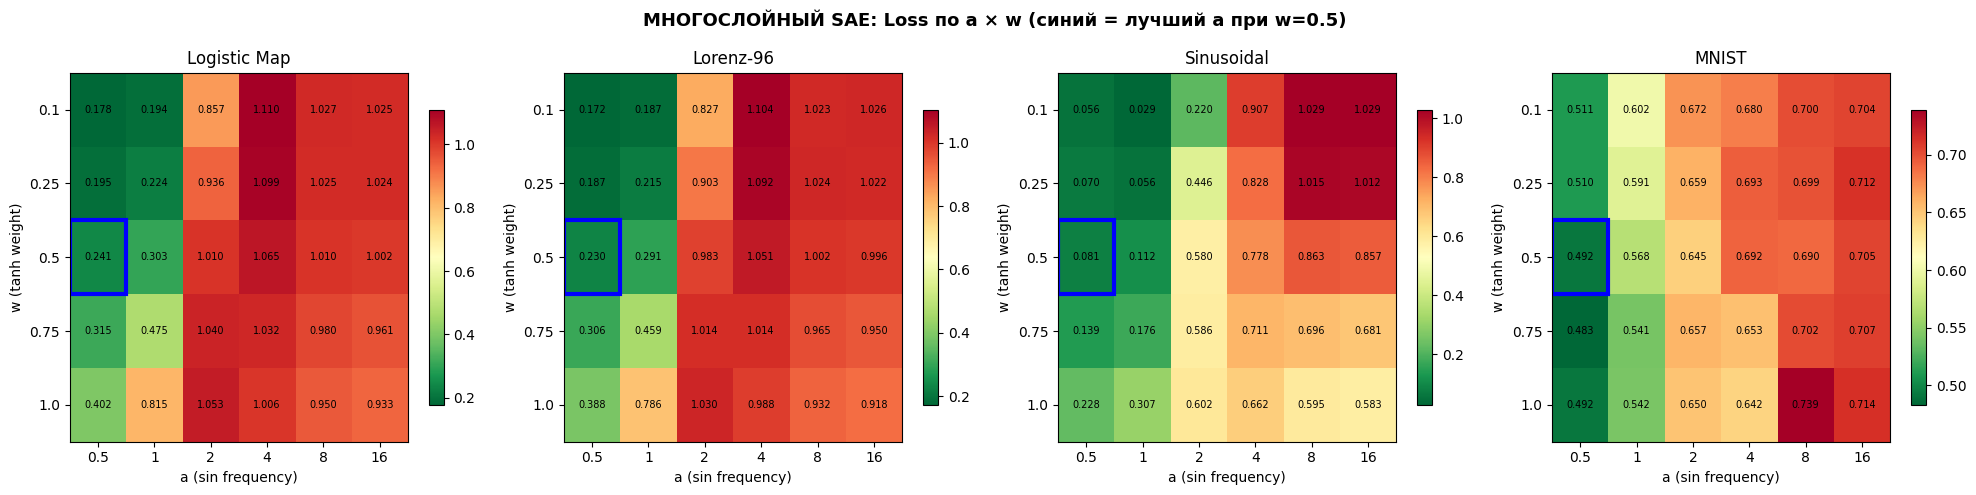


Оптимальный a (многослойный, w=0.5):
  Logistic Map   : a = 0.5
  Lorenz-96      : a = 0.5
  Sinusoidal     : a = 0.5
  MNIST          : a = 0.5


In [5]:
# === Heatmaps + сравнение с тестом 22 ===

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

optimal_a_multi = {}

# Оптимальные a из теста 22 (однослойный) — заполним после запуска
# Пока placeholder, обновить вручную
optimal_a_single = {}  # будет заполнено ниже

for idx, (domain_name, domain_results) in enumerate(sweep_results.items()):
    loss_matrix = np.zeros((len(W_VALUES), len(A_VALUES)))
    for i, w in enumerate(W_VALUES):
        for j, a in enumerate(A_VALUES):
            loss_matrix[i, j] = domain_results[(a, w)]['loss_mean']
    
    im = axes[idx].imshow(loss_matrix, cmap='RdYlGn_r', aspect='auto')
    axes[idx].set_xticks(range(len(A_VALUES)))
    axes[idx].set_xticklabels(A_VALUES)
    axes[idx].set_yticks(range(len(W_VALUES)))
    axes[idx].set_yticklabels(W_VALUES)
    axes[idx].set_xlabel('a (sin frequency)')
    axes[idx].set_ylabel('w (tanh weight)')
    axes[idx].set_title(f'{domain_name}')
    plt.colorbar(im, ax=axes[idx], shrink=0.8)
    
    for i in range(len(W_VALUES)):
        for j in range(len(A_VALUES)):
            axes[idx].text(j, i, f'{loss_matrix[i,j]:.3f}', ha='center', va='center', fontsize=7)
    
    # Лучший a при w=0.5
    w_idx = W_VALUES.index(0.5)
    losses_at_w05 = [domain_results[(a, 0.5)]['loss_mean'] for a in A_VALUES]
    best_a_idx = np.argmin(losses_at_w05)
    best_a = A_VALUES[best_a_idx]
    optimal_a_multi[domain_name] = best_a
    axes[idx].add_patch(plt.Rectangle((best_a_idx-0.5, w_idx-0.5), 1, 1,
                                       fill=False, edgecolor='blue', lw=3))

plt.suptitle('МНОГОСЛОЙНЫЙ SAE: Loss по a × w (синий = лучший a при w=0.5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nОптимальный a (многослойный, w=0.5):')
for name, a in optimal_a_multi.items():
    print(f'  {name:15s}: a = {a}')

In [6]:
# === Сравнение: однослойный (тест 22) vs многослойный (тест 23) ===

# Загрузка результатов теста 22
import glob
t22_files = sorted(glob.glob('../jsons/coefficient_justification_*.json'))
if t22_files:
    with open(t22_files[-1]) as f:
        t22_data = json.load(f)
    optimal_a_single = t22_data.get('optimal_a_per_domain', {})
    print('Загружены результаты теста 22')
else:
    optimal_a_single = {
        'Logistic Map': 0.5,
        'Lorenz-96': 1,
        'Sinusoidal': 1,
        'MNIST': 0.5,
    }
    print('Результаты теста 22 введены вручную')

print('\n' + '=' * 70)
print('СРАВНЕНИЕ: оптимальный a (при w=0.5)')
print('=' * 70)
header = f"{'Домен':15s} {'Однослойный':>12} {'Многослойный':>13} {'Сдвиг':>8}"
print(header)
print('-' * 55)
for name in domains.keys():
    a_single = optimal_a_single.get(name, '?')
    a_multi = optimal_a_multi.get(name, '?')
    if isinstance(a_single, (int, float)) and isinstance(a_multi, (int, float)):
        ratio = a_multi / a_single if a_single > 0 else float('inf')
        print(f'{name:15s} {a_single:>12} {a_multi:>13} {ratio:>7.1f}x')
    else:
        print(f'{name:15s} {a_single:>12} {a_multi:>13}')

# Dead neurons сравнение
print()
header2 = f"{'Домен':15s} {'a':>4} {'w':>4} {'Multi dead':>11} {'Multi loss':>11}"
print(header2)
print('-' * 55)
for name in domains.keys():
    a_opt = optimal_a_multi[name]
    r = sweep_results[name][(a_opt, 0.5)]
    print(f"{name:15s} {a_opt:>4} {0.5:>4} {r['dead_mean']:>9.1f} {r['loss_mean']:>11.4f}")

Загружены результаты теста 22

СРАВНЕНИЕ: оптимальный a (при w=0.5)
Домен            Однослойный  Многослойный    Сдвиг
-------------------------------------------------------
Logistic Map             0.5           0.5     1.0x
Lorenz-96                  1           0.5     0.5x
Sinusoidal                 1           0.5     0.5x
MNIST                    0.5           0.5     1.0x

Домен              a    w  Multi dead  Multi loss
-------------------------------------------------------
Logistic Map     0.5  0.5       0.0      0.2414
Lorenz-96        0.5  0.5       0.0      0.2297
Sinusoidal       0.5  0.5       0.0      0.0814
MNIST            0.5  0.5       0.0      0.4916


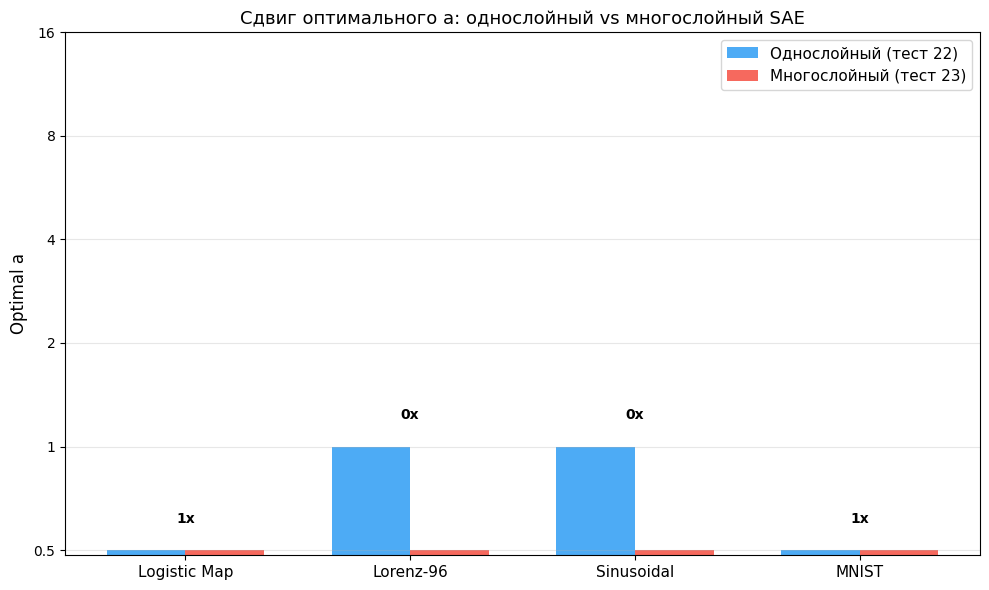

In [7]:
# === Визуализация сдвига a ===

fig, ax = plt.subplots(figsize=(10, 6))

domain_names = list(domains.keys())
x_pos = np.arange(len(domain_names))
width = 0.35

a_singles = [optimal_a_single.get(n, 1) for n in domain_names]
a_multis = [optimal_a_multi.get(n, 1) for n in domain_names]

bars1 = ax.bar(x_pos - width/2, a_singles, width, label='Однослойный (тест 22)',
               color='#2196F3', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, a_multis, width, label='Многослойный (тест 23)',
               color='#F44336', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(domain_names, fontsize=11)
ax.set_ylabel('Optimal a', fontsize=12)
ax.set_title('Сдвиг оптимального a: однослойный vs многослойный SAE', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_yscale('log', base=2)
ax.set_yticks([0.5, 1, 2, 4, 8, 16])
ax.set_yticklabels([0.5, 1, 2, 4, 8, 16])

# Аннотации
for i, (s, m) in enumerate(zip(a_singles, a_multis)):
    if s > 0:
        ratio = m / s
        ax.annotate(f'{ratio:.0f}x', xy=(i, max(s, m) * 1.2),
                    ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# === Сохранение ===
save_data = {
    'experiment': 'coefficient_multilayer',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'architecture': 'multilayer: input->256->latent->256->output',
        'a_values': A_VALUES,
        'w_values': W_VALUES,
        'b_fixed': B_FIXED,
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
        'input_dim': INPUT_DIM,
        'latent_dim': LATENT_DIM,
        'k_active': K_ACTIVE,
    },
    'optimal_a_multilayer': optimal_a_multi,
    'optimal_a_singlelayer': optimal_a_single,
    'sweep_results': {
        domain: {f'a={k[0]}_w={k[1]}': v for k, v in res.items()}
        for domain, res in sweep_results.items()
    },
}

json_path = f"../jsons/coefficient_multilayer_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f'Results saved: {json_path}')

Results saved: ../jsons/coefficient_multilayer_20260416_121730.json
